Vamos a generar los datos del ejemplo 1.2, pero redefiniremos W para ser R.

In [165]:
import numpy as np
import matplotlib.pyplot as plt

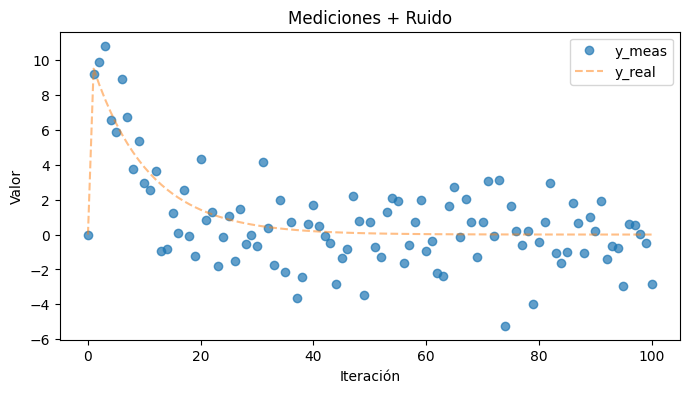

In [166]:
n, m = 2, 100
seed = 42
np.random.seed(seed)

x = np.array([0.9048, 0.0952]).reshape((2,1)) # PHI, GAMMA
y_real = np.zeros((m + 1, 1))
y_real[0] = 0
y_meas = np.zeros_like(y_real)

u = np.zeros((m + 1, 1))
u[0] = 100

sigma = 2.
v = np.random.normal(loc=0, scale=sigma, size=y_meas.shape)

for i in range(1, m + 1):
    y_real[i] = x[0] * y_real[i-1] + x[1] * u[i-1]
    y_meas[i] = y_real[i] + v[i]

t = np.arange(m + 1)

plt.figure(figsize=(8,4))
plt.title("Mediciones + Ruido")
plt.plot(t, y_meas, 'o', alpha=0.7, label='y_meas')
plt.plot(t, y_real, '--', alpha=0.5, label='y_real')
plt.ylabel("Valor")
plt.xlabel("Iteración")
plt.legend()
plt.show()

In [167]:
H = np.hstack((y_meas[:-1], u[:-1]))
R = np.cov(v[1:] @ v[1:].T + np.eye(m)*1e-5)

R_inv = np.linalg.inv(R)
x_est_prev = np.linalg.inv(H.T @ H) @ H.T @ y_meas[1:]
x_est_R = np.linalg.inv(H.T @ R_inv @ H) @ H.T @ R_inv @ y_meas[1:]

print("Resultados")
print(f"Original: {x.flatten()}")
print(f"Estimación pelada: {x_est_prev.flatten()}")
print(f"Estimación con R: {x_est_R.flatten()}")

Resultados
Original: [0.9048 0.0952]
Estimación pelada: [0.55786801 0.09243471]
Estimación con R: [0.7830329  0.12056147]


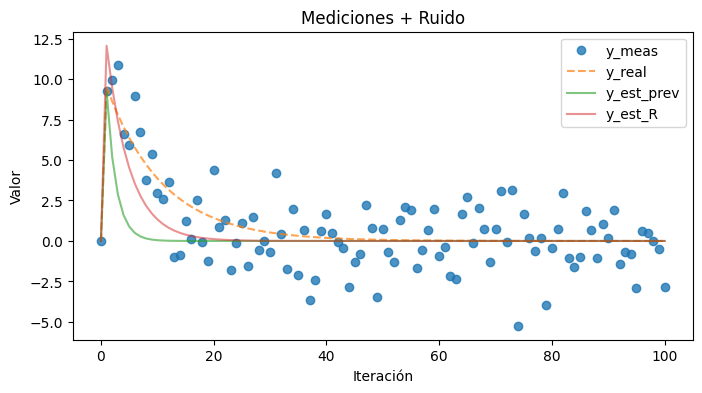

In [168]:
y_est_prev = np.zeros_like(y_meas)
y_est_R = np.zeros_like(y_meas)

for i in range(1, m + 1):
    y_est_prev[i] = x_est_prev[0] * y_est_prev[i-1] + x_est_prev[1] * u[i-1]
    y_est_R[i] = x_est_R[0] * y_est_R[i-1] + x_est_R[1] * u[i-1]

plt.figure(figsize=(8,4))
plt.title("Mediciones + Ruido")
plt.plot(t, y_meas, 'o', alpha=0.8, label='y_meas')
plt.plot(t, y_real, '--', alpha=0.7, label='y_real')
plt.plot(t, y_est_prev, alpha=0.6, label='y_est_prev')
plt.plot(t, y_est_R, alpha=0.5, label='y_est_R')
plt.ylabel("Valor")
plt.xlabel("Iteración")
plt.legend()
plt.show()